## Imports & configuration

In [1]:
import json
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("pandas version:", pd.__version__)
print("numpy version :", np.__version__)


pandas version: 3.0.5
numpy version : 2.5.3


## Project paths

Paths are resolved relative to this notebook's location (`pipelines/`), exactly like
`segmentation_model_v2.ipynb` and `segment_labeling.ipynb` -- no machine-specific
absolute paths.


In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent  # this notebook lives in pipelines/

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
MODELS_DIR = ARTIFACTS_DIR / "models"
PREPROCESSING_DIR = ARTIFACTS_DIR / "preprocessing"
METADATA_DIR = ARTIFACTS_DIR / "metadata"

# New output directory for this notebook's results. Created programmatically --
# nothing needs to exist beforehand. Named "outputs/" at the project root, which is
# both the literal deliverable name the assignment README uses ("segments.jsonl")
# and consistent with the existing artifacts/ / pipelines/ / notebooks/ layout.
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
print("Outputs will be written to:", OUTPUTS_DIR)


Outputs will be written to: c:\Users\Shambhavi Singh\OneDrive\Desktop\IBY_PROJECT\outputs


## Locate Dataset B

Reuses the exact same search strategy as the existing notebooks (search for a directory
whose direct children are `ses_*` folders), so this works regardless of whether Dataset B
sits under `notebooks/dataset_B/`, a top-level `dataset_B/`, or next to this notebook --
without hardcoding a machine-specific path.


In [3]:
def _has_session_children(directory: Path) -> bool:
    try:
        return any(
            child.is_dir() and child.name.startswith("ses_")
            for child in directory.iterdir()
        )
    except (PermissionError, FileNotFoundError):
        return False


def find_dataset_sessions_root(search_roots, dataset_label, max_depth=3):
    tried = []
    seen = set()
    frontier = [(root, 0) for root in search_roots if root.exists()]
    while frontier:
        current, depth = frontier.pop(0)
        if current in seen:
            continue
        seen.add(current)
        tried.append(current)
        if _has_session_children(current):
            return current
        if depth < max_depth:
            try:
                for child in current.iterdir():
                    if child.is_dir():
                        frontier.append((child, depth + 1))
            except (PermissionError, FileNotFoundError):
                continue
    raise FileNotFoundError(
        f"Could not locate a sessions folder for {dataset_label}.\n"
        f"Checked {len(tried)} candidate directories, including:\n"
        + "\n".join(f"  - {p}" for p in tried[:15])
    )


dataset_b_search_roots = [
    PROJECT_ROOT / "notebooks" / "dataset_B",
    PROJECT_ROOT / "dataset_B",
    NOTEBOOK_DIR / "dataset_B",
]

DATASET_B_DIR = find_dataset_sessions_root(dataset_b_search_roots, "Dataset B")
print("Dataset B sessions root:", DATASET_B_DIR)

dataset_b_sessions = sorted([
    p for p in DATASET_B_DIR.iterdir() if p.is_dir() and p.name.startswith("ses_")
])
print("Sessions found:", len(dataset_b_sessions), "(expected ~15 per the assignment brief)")


Dataset B sessions root: c:\Users\Shambhavi Singh\OneDrive\Desktop\IBY_PROJECT\notebooks\dataset_B\dataset_b-20260909T170638Z-1-001\dataset_b
Sessions found: 15 (expected ~15 per the assignment brief)


##  Load existing models and preprocessors

Only the **boundary detector** (segmentation model) is loaded here for inference.
The Dataset A **labeler** is deliberately *not* loaded for reuse -- see Section 1 and the
printed `reason_not_reusable` below, sourced directly from the repository's own metadata
rather than asserted by this notebook.


In [4]:
boundary_model = joblib.load(MODELS_DIR / "best_segmentation_model.pkl")
boundary_preprocessor = joblib.load(PREPROCESSING_DIR / "best_preprocessor.pkl")

with open(METADATA_DIR / "segmentation_model_metadata.json", "r", encoding="utf-8") as f:
    boundary_metadata = json.load(f)

with open(METADATA_DIR / "segment_labeler_dataset_a_metadata.json", "r", encoding="utf-8") as f:
    labeler_a_metadata = json.load(f)

print("Boundary model  :", type(boundary_model).__name__, "-", boundary_metadata["model_name"])
print("Boundary version:", boundary_metadata["model_version"])
print()
print("Dataset A labeler reusable on Dataset B?", labeler_a_metadata["reusable_on_dataset_b"])
print("Reason (from the repository's own metadata):")
print(" ", labeler_a_metadata["reason_not_reusable"])


Boundary model  : CatBoostClassifier - CatBoost
Boundary version: V2_context_shift_candidates_resume_aware

Dataset A labeler reusable on Dataset B? False
Reason (from the repository's own metadata):
  Dataset B has a completely different set of business processes (different department, different applications). This clusterer's cluster centers/structure are specific to Dataset A's 15 processes and have no meaningful correspondence on Dataset B. Dataset B requires refitting this SAME APPROACH from scratch on its own segments.


Inspect model metadata\n\nConfiguration (thresholds, feature list, candidate event types) is read from the saved metadata rather than hardcoded, so this notebook cannot silently drift from what was actually trained and saved.

In [5]:
BOUNDARY_EVENT_TYPES = set(boundary_metadata["boundary_event_types_used_as_candidates"])
FEATURE_COLUMNS = boundary_metadata["feature_columns"]
CATEGORICAL_FEATURES = boundary_metadata["categorical_features"]
NUMERIC_FEATURES = boundary_metadata["numeric_features"]
BOUNDARY_THRESHOLD = boundary_metadata["boundary_threshold"]
MIN_SEGMENT_DURATION_S = boundary_metadata["min_segment_duration_seconds"]

print("Candidate event types      :", sorted(BOUNDARY_EVENT_TYPES))
print("Feature columns (", len(FEATURE_COLUMNS), "):", FEATURE_COLUMNS)
print("Boundary probability threshold :", BOUNDARY_THRESHOLD)
print("Min segment duration (merge)   :", MIN_SEGMENT_DURATION_S, "s")
print()
print("Dataset A test-set performance (for context only -- NOT expected to transfer 1:1 to B):")
print("  boundary F1@2000ms   :", round(boundary_metadata["test_boundary_f1_2000ms"], 3))
print("  segment IoU50 F1     :", round(boundary_metadata["test_segment_iou50_f1"], 3))


Candidate event types      : ['app_switch', 'browser_navigation', 'browser_tab_event', 'dialog_closed', 'dialog_opened', 'window_state_change', 'window_title_change']
Feature columns ( 16 ): ['event_type', 'layer', 'gap_before_candidate_s', 'time_since_prev_event_s', 'time_since_session_start_s', 'app_changed', 'title_changed', 'events_in_prior_10s', 'events_in_next_10s', 'is_app_switch', 'is_browser_navigation', 'is_browser_tab_event', 'is_dialog_closed', 'is_dialog_opened', 'is_window_state_change', 'is_window_title_change']
Boundary probability threshold : 0.95
Min segment duration (merge)   : 15 s

Dataset A test-set performance (for context only -- NOT expected to transfer 1:1 to B):
  boundary F1@2000ms   : 0.799
  segment IoU50 F1     : 0.727


##  Load Dataset B raw events

Identical loader to `segment_labeling.ipynb` (includes `context.extracted_text`, which is
not needed for boundary detection but is used later for the segment-labeling features and
for a text-coverage sanity check). `session_dir.rglob("events.jsonl")` walks **all** chunk
subfolders under a session directory and concatenates them, so a session split across
multiple chunks (Critical Requirement #4) is naturally reconstructed as one continuous
stream -- sorting is by `(timestamp, sequence_number)`, not by chunk, so chunk boundaries
never leak into the segmentation logic.


In [6]:
def load_session_events(session_dir: Path) -> pd.DataFrame:
    event_files = sorted(session_dir.rglob("events.jsonl"))
    if not event_files:
        raise FileNotFoundError(f"No events.jsonl files found under {session_dir}")

    records = []
    malformed_line_count = 0

    for event_file in event_files:
        chunk_dir_name = event_file.parent.name
        with open(event_file, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    event = json.loads(line)
                except json.JSONDecodeError:
                    malformed_line_count += 1
                    continue

                context = event.get("context") or {}
                active_app = context.get("active_app") or {}
                correlation = event.get("correlation") or {}

                records.append({
                    "session_id": session_dir.name,
                    "event_id": event.get("event_id"),
                    "timestamp_iso": event.get("timestamp_iso"),
                    "layer": event.get("layer"),
                    "event_type": event.get("event_type"),
                    "active_app_name": active_app.get("app_name"),
                    "active_window_title": active_app.get("window_title"),
                    "extracted_text": context.get("extracted_text"),
                    "sequence_number": correlation.get("sequence_number"),
                    "source_chunk_dir": chunk_dir_name,
                })

    if malformed_line_count:
        print(f"  WARNING: skipped {malformed_line_count} malformed line(s) in {session_dir.name}")

    events_df = pd.DataFrame.from_records(records)
    if events_df.empty:
        return events_df
    events_df["timestamp"] = pd.to_datetime(
        events_df["timestamp_iso"].str.replace("Z", "+00:00", regex=False),
        utc=True,
        errors="coerce",
    )
    events_df = events_df.sort_values(
        by=["timestamp", "sequence_number"], kind="mergesort", na_position="last"
    ).reset_index(drop=True)
    return events_df


_start = time.perf_counter()
_frames = []
failed_sessions = []
for session_dir in dataset_b_sessions:
    try:
        session_df = load_session_events(session_dir)
        if session_df.empty:
            failed_sessions.append((session_dir.name, "no events after parsing"))
            continue
        _frames.append(session_df)
    except Exception as exc:  # noqa: BLE001 -- we want to keep going and report ALL failures
        failed_sessions.append((session_dir.name, str(exc)))

if not _frames:
    raise RuntimeError("No Dataset B sessions could be loaded -- check DATASET_B_DIR contents.")

ALL_EVENTS_B = pd.concat(_frames, ignore_index=True)
print(f"Loaded {len(ALL_EVENTS_B):,} events from {len(_frames)} session(s) in {time.perf_counter() - _start:.1f}s")
if failed_sessions:
    print("\nSessions that FAILED to load (excluded from the rest of the pipeline):")
    for name, reason in failed_sessions:
        print(f"  - {name}: {reason}")
else:
    print("All discovered sessions loaded successfully.")


Loaded 20,477 events from 15 session(s) in 2.9s
All discovered sessions loaded successfully.


## Reconstruct sessions across chunks & 8. Validate event ordering / timestamps

Reconstruction already happened in the loader above (`rglob` + global sort). This section
only *verifies* it worked: chronological ordering per session, no NaT timestamps, and a
look at how many sessions actually span multiple chunks (confirms Critical Requirement #4
is real in this data, not just a hypothetical).


In [7]:
validation_issues = []

# 1. Monotonic timestamps per session
non_monotonic_sessions = []
for session_id, group in ALL_EVENTS_B.groupby("session_id"):
    if not group["timestamp"].is_monotonic_increasing:
        non_monotonic_sessions.append(session_id)
if non_monotonic_sessions:
    validation_issues.append(f"{len(non_monotonic_sessions)} session(s) not monotonically sorted: {non_monotonic_sessions}")

# 2. Unparseable timestamps
n_bad_ts = ALL_EVENTS_B["timestamp"].isna().sum()
if n_bad_ts:
    validation_issues.append(f"{n_bad_ts} event(s) with unparseable timestamp_iso")

# 3. Multi-chunk sessions
chunks_per_session = ALL_EVENTS_B.groupby("session_id")["source_chunk_dir"].nunique()
multi_chunk_sessions = chunks_per_session[chunks_per_session > 1]
print(f"Sessions spanning multiple chunks: {len(multi_chunk_sessions)} / {len(chunks_per_session)}")
if len(multi_chunk_sessions) > 0:
    print(multi_chunk_sessions.to_string())

print()
if validation_issues:
    print("VALIDATION ISSUES FOUND:")
    for issue in validation_issues:
        print(" -", issue)
else:
    print("Event ordering and timestamps: OK (all sessions monotonic, no unparseable timestamps).")


Sessions spanning multiple chunks: 5 / 15
session_id
ses_20260701-171614-CHAITANYA0BCF      2
ses_20260701-175258-LAPTOP-76QMG9DE    2
ses_20260701-175747-SIDDHIGUPTAB00B    2
ses_20260701-182634-NEELA9BAF          2
ses_20260701-192455-NEELA9BAF          2

Event ordering and timestamps: OK (all sessions monotonic, no unparseable timestamps).


## Feature engineering / preprocessing -- boundary detection

This block is a line-for-line port of the candidate + feature construction in
`segmentation_model_v2.ipynb` / `segment_labeling.ipynb`, applied to `ALL_EVENTS_B` instead
of `ALL_EVENTS_A`. Nothing about the feature *definitions* changes -- only the input data.

One ordering detail matters and is preserved deliberately: candidates are sliced out of the
raw events **before** `time_since_prev_event_s` is added to the raw-event table, exactly as
in the original notebooks. Reordering this (computing the column first, then slicing) creates
a duplicate-column merge collision -- this was caught while dry-running this exact pipeline
against a small schema-conformant synthetic dataset before finalizing this notebook.


In [8]:
ALL_EVENTS_B = ALL_EVENTS_B.sort_values(["session_id", "timestamp"]).reset_index(drop=True)

CANDIDATES = ALL_EVENTS_B[ALL_EVENTS_B["event_type"].isin(BOUNDARY_EVENT_TYPES)].copy()
n_before_dedup = len(CANDIDATES)
CANDIDATES = CANDIDATES.drop_duplicates(subset=["session_id", "timestamp"], keep="first")
CANDIDATES = CANDIDATES.sort_values(["session_id", "timestamp"]).reset_index(drop=True)
print("Exact-timestamp duplicate candidates removed:", n_before_dedup - len(CANDIDATES))
print(f"Candidate boundary events: {len(CANDIDATES)} ({len(CANDIDATES) / len(ALL_EVENTS_B):.1%} of all raw events)")
print("\nBreakdown by event_type:")
print(CANDIDATES["event_type"].value_counts())

# --- gap before this candidate, relative to the previous RAW event of any type ---
ALL_EVENTS_B["time_since_prev_event_s"] = (
    ALL_EVENTS_B.groupby("session_id")["timestamp"].diff().dt.total_seconds()
)
CANDIDATES = CANDIDATES.merge(
    ALL_EVENTS_B[["event_id", "time_since_prev_event_s"]], on="event_id", how="left",
)
CANDIDATES = CANDIDATES.sort_values(["session_id", "timestamp"]).reset_index(drop=True)

# --- gap before this candidate, relative to the previous CANDIDATE ---
CANDIDATES["gap_before_candidate_s"] = (
    CANDIDATES.groupby("session_id")["timestamp"].diff().dt.total_seconds()
)

# --- time since session start ---
session_start_map = ALL_EVENTS_B.groupby("session_id")["timestamp"].min()
CANDIDATES["time_since_session_start_s"] = (
    CANDIDATES["timestamp"] - CANDIDATES["session_id"].map(session_start_map)
).dt.total_seconds()

# --- did the actual app/window title change vs. the previous candidate? ---
CANDIDATES["prev_app_name"] = CANDIDATES.groupby("session_id")["active_app_name"].shift(1)
CANDIDATES["prev_window_title"] = CANDIDATES.groupby("session_id")["active_window_title"].shift(1)
CANDIDATES["app_changed"] = (CANDIDATES["active_app_name"] != CANDIDATES["prev_app_name"]).astype(int)
CANDIDATES["title_changed"] = (CANDIDATES["active_window_title"] != CANDIDATES["prev_window_title"]).astype(int)

# --- one-hot style flags for the restricted event types ---
for event_type_name in sorted(BOUNDARY_EVENT_TYPES):
    CANDIDATES[f"is_{event_type_name}"] = (CANDIDATES["event_type"] == event_type_name).astype(int)


def count_events_in_window(session_events_ns, target_ns, window_ms, direction):
    if direction == "prior":
        lo = target_ns - window_ms * 1_000_000
        left = np.searchsorted(session_events_ns, lo, side="left")
        right = np.searchsorted(session_events_ns, target_ns, side="left")
    else:
        hi = target_ns + window_ms * 1_000_000
        left = np.searchsorted(session_events_ns, target_ns, side="right")
        right = np.searchsorted(session_events_ns, hi, side="right")
    return right - left


def add_window_counts(candidates_df, events_df, window_ms, direction, colname):
    counts = np.zeros(len(candidates_df), dtype=int)
    candidates_df = candidates_df.reset_index(drop=True)
    for session_id, cand_group in candidates_df.groupby("session_id"):
        session_events_ns = (
            events_df.loc[events_df["session_id"] == session_id, "timestamp"]
            .sort_values().values.astype("datetime64[ns]").astype("int64")
        )
        target_ns = cand_group["timestamp"].values.astype("datetime64[ns]").astype("int64")
        counts[cand_group.index.values] = count_events_in_window(
            session_events_ns, target_ns, window_ms, direction
        )
    candidates_df[colname] = counts
    return candidates_df


CANDIDATES = add_window_counts(CANDIDATES, ALL_EVENTS_B, 10000, "prior", "events_in_prior_10s")
CANDIDATES = add_window_counts(CANDIDATES, ALL_EVENTS_B, 10000, "next", "events_in_next_10s")

CANDIDATES[NUMERIC_FEATURES] = CANDIDATES[NUMERIC_FEATURES].fillna(0)

missing_features = set(FEATURE_COLUMNS) - set(CANDIDATES.columns)
assert not missing_features, f"Feature schema mismatch -- Dataset B is missing: {missing_features}"
print("\nFeature schema check: OK -- all", len(FEATURE_COLUMNS), "expected columns are present.")
print("Candidate feature table shape:", CANDIDATES.shape)


Exact-timestamp duplicate candidates removed: 1
Candidate boundary events: 2163 (10.6% of all raw events)

Breakdown by event_type:
event_type
app_switch             1654
browser_navigation      203
window_title_change     186
window_state_change     120
Name: count, dtype: int64

Feature schema check: OK -- all 16 expected columns are present.
Candidate feature table shape: (2163, 27)


##  Apply the segmentation model & 11-12. Convert predictions into segment boundaries

Threshold (`0.95`) and the minimum-segment-duration merge (`15s`) are both read from the
saved metadata, not re-derived here -- reusing exactly what Dataset A's evaluation already
validated (Critical Requirement #2, and the assignment's `QUALITY CHECKS` instruction to
reuse existing thresholds rather than inventing new ones).

One adaptation relative to the original notebook: the original only ever built segments for
sessions that had **at least one** predicted boundary (it iterated over
`test_data[boundary_prediction == 1].groupby(...)`). On Dataset B, a session with *zero*
predicted boundaries is a realistic and important outcome (e.g. a short session doing one
continuous task) and must still appear in the output as a single whole-session segment,
not be silently dropped. This notebook iterates over **every** Dataset B session explicitly
and falls back to `[session_start]` as the only boundary when the model predicts none.


In [9]:
X_all = CANDIDATES[FEATURE_COLUMNS]
X_all_proc = boundary_preprocessor.transform(X_all)
boundary_probabilities = boundary_model.predict_proba(X_all_proc)[:, 1]

CANDIDATES["boundary_probability"] = boundary_probabilities
CANDIDATES["boundary_prediction"] = (boundary_probabilities >= BOUNDARY_THRESHOLD).astype(int)

print("Predicted boundaries across all Dataset B candidates (pre-merge):",
      int(CANDIDATES["boundary_prediction"].sum()), "/", len(CANDIDATES))


def merge_short_segments(boundary_timestamps, min_duration_s):
    if len(boundary_timestamps) == 0:
        return []
    kept = [boundary_timestamps[0]]
    for ts in boundary_timestamps[1:]:
        if (ts - kept[-1]).total_seconds() >= min_duration_s:
            kept.append(ts)
    return kept


def boundaries_to_segments(boundary_ts, session_id, session_start_ts, session_end_ts):
    starts = list(boundary_ts)
    if not starts or starts[0] > session_start_ts:
        # Guarantee full session coverage: activity before the first detected
        # boundary (or an entire boundary-free session) is still one segment,
        # never silently dropped from the output.
        starts = [session_start_ts] + starts
    ends = starts[1:] + [session_end_ts]
    return pd.DataFrame({"session_id": session_id, "pred_start": starts, "pred_end": ends})


session_bounds = ALL_EVENTS_B.groupby("session_id")["timestamp"].agg(["min", "max"])

predicted_segments_list = []
sessions_with_no_predicted_boundary = []
for session_id in ALL_EVENTS_B["session_id"].unique():
    session_start_ts = session_bounds.loc[session_id, "min"]
    session_end_ts = session_bounds.loc[session_id, "max"]

    session_candidates = CANDIDATES[
        (CANDIDATES["session_id"] == session_id) & (CANDIDATES["boundary_prediction"] == 1)
    ]
    boundary_ts = sorted(session_candidates["timestamp"].tolist())
    merged_ts = merge_short_segments(boundary_ts, MIN_SEGMENT_DURATION_S)

    if not merged_ts:
        sessions_with_no_predicted_boundary.append(session_id)

    predicted_segments_list.append(
        boundaries_to_segments(merged_ts, session_id, session_start_ts, session_end_ts)
    )

PREDICTED_SEGMENTS_B = pd.concat(predicted_segments_list, ignore_index=True)
PREDICTED_SEGMENTS_B["pred_duration_s"] = (
    PREDICTED_SEGMENTS_B["pred_end"] - PREDICTED_SEGMENTS_B["pred_start"]
).dt.total_seconds()

print("Total predicted segments across Dataset B:", len(PREDICTED_SEGMENTS_B))
print("Sessions with zero predicted boundaries (whole session = one segment):",
      len(sessions_with_no_predicted_boundary))
if sessions_with_no_predicted_boundary:
    for sid in sessions_with_no_predicted_boundary:
        print("  -", sid)


Predicted boundaries across all Dataset B candidates (pre-merge): 83 / 2163
Total predicted segments across Dataset B: 98
Sessions with zero predicted boundaries (whole session = one segment): 1
  - ses_20260701-192455-NEELA9BAF


##  Assign process labels






###  Per-segment behavioral features (+ extracted_text coverage check)

In [10]:
events_by_session = ALL_EVENTS_B.groupby("session_id")


def get_segment_events(session_id, start_ts, end_ts, events_by_session_grouped):
    if session_id not in events_by_session_grouped.groups:
        return pd.DataFrame(columns=ALL_EVENTS_B.columns)
    session_events = events_by_session_grouped.get_group(session_id)
    # Right edge is inclusive when end_ts is the session's own last timestamp (the final
    # segment of a session), otherwise exclusive -- avoids both double-counting an event at
    # an interior boundary AND silently dropping the single event that sits exactly at the
    # session's final timestamp (a real edge case caught by the Section 15 coverage check).
    session_max_ts = session_events["timestamp"].max()
    if end_ts >= session_max_ts:
        mask = (session_events["timestamp"] >= start_ts) & (session_events["timestamp"] <= end_ts)
    else:
        mask = (session_events["timestamp"] >= start_ts) & (session_events["timestamp"] < end_ts)
    return session_events.loc[mask]


# --- extracted_text coverage (diagnostic only, mirrors segment_labeling.ipynb Cell 5) ---
has_text_flags, text_event_counts = [], []
for _, seg in PREDICTED_SEGMENTS_B.iterrows():
    seg_events = get_segment_events(seg["session_id"], seg["pred_start"], seg["pred_end"], events_by_session)
    n_text = seg_events["extracted_text"].notna().sum()
    has_text_flags.append(n_text > 0)
    text_event_counts.append(n_text)

PREDICTED_SEGMENTS_B["has_any_extracted_text"] = has_text_flags
PREDICTED_SEGMENTS_B["n_extracted_text_events"] = text_event_counts
coverage_b = PREDICTED_SEGMENTS_B["has_any_extracted_text"].mean()
print(f"Extracted-text segment coverage on Dataset B: {coverage_b:.1%}")
print("(Kept as a diagnostic only -- the existing labeling approach does not feed this into")
print(" clustering; see the note above on the A metadata / code discrepancy.)")

EVENT_TYPE_FEATURE_LIST = [
    "keystroke", "mouse_click", "mouse_double_click", "mouse_scroll",
    "clipboard_change", "shortcut", "browser_click", "browser_form_input",
    "browser_navigation", "screenshot_smart",
]

feature_records = []
for _, seg in PREDICTED_SEGMENTS_B.iterrows():
    seg_events = get_segment_events(seg["session_id"], seg["pred_start"], seg["pred_end"], events_by_session)
    n_events = len(seg_events)

    record = {
        "session_id": seg["session_id"],
        "pred_start": seg["pred_start"],
        "pred_end": seg["pred_end"],
        "duration_s": seg["pred_duration_s"],
        "n_events": n_events,
        "n_distinct_apps": seg_events["active_app_name"].nunique(),
        "dominant_app": (
            seg_events["active_app_name"].mode().iloc[0]
            if n_events > 0 and not seg_events["active_app_name"].mode().empty
            else "unknown"
        ),
        "hour_of_day": seg["pred_start"].hour,
    }
    for event_type_name in EVENT_TYPE_FEATURE_LIST:
        record[f"frac_{event_type_name}"] = (
            (seg_events["event_type"] == event_type_name).sum() / n_events if n_events > 0 else 0.0
        )
    feature_records.append(record)

SEGMENT_FEATURES_B = pd.DataFrame(feature_records)
SEGMENT_FEATURES_B["hour_sin"] = np.sin(2 * np.pi * SEGMENT_FEATURES_B["hour_of_day"] / 24)
SEGMENT_FEATURES_B["hour_cos"] = np.cos(2 * np.pi * SEGMENT_FEATURES_B["hour_of_day"] / 24)

# Top-K apps computed FROM DATASET B ITSELF (Dataset B uses different applications
# than Dataset A, so Dataset A's top-app vocabulary would not apply here).
TOP_K_APPS = 12
top_apps_b = SEGMENT_FEATURES_B["dominant_app"].value_counts().head(TOP_K_APPS).index.tolist()
SEGMENT_FEATURES_B["dominant_app_grouped"] = SEGMENT_FEATURES_B["dominant_app"].where(
    SEGMENT_FEATURES_B["dominant_app"].isin(top_apps_b), "other"
)

print("\nSegment feature table shape:", SEGMENT_FEATURES_B.shape)
print("\nTop dominant apps on Dataset B:")
print(SEGMENT_FEATURES_B["dominant_app_grouped"].value_counts())


Extracted-text segment coverage on Dataset B: 96.9%
(Kept as a diagnostic only -- the existing labeling approach does not feed this into
 clustering; see the note above on the A metadata / code discrepancy.)

Segment feature table shape: (98, 21)

Top dominant apps on Dataset B:
dominant_app_grouped
Microsoft Edge            87
Microsoft Word             6
WindowsTerminal            2
procmine-desktop-agent     1
Microsoft Excel            1
OpenWith                   1
Name: count, dtype: int64


###  Fit clustering (KMeans + HDBSCAN, silhouette-selected -- no ground truth used)

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.metrics import silhouette_score

LABEL_CATEGORICAL_FEATURES = ["dominant_app_grouped"]
LABEL_NUMERIC_FEATURES = (
    ["duration_s", "n_events", "n_distinct_apps", "hour_sin", "hour_cos"]
    + [f"frac_{name}" for name in EVENT_TYPE_FEATURE_LIST]
)

label_preprocessor_b = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), LABEL_CATEGORICAL_FEATURES),
    ("numeric", StandardScaler(), LABEL_NUMERIC_FEATURES),
])

X_label_features_b = SEGMENT_FEATURES_B[LABEL_CATEGORICAL_FEATURES + LABEL_NUMERIC_FEATURES]
X_label_proc_b = label_preprocessor_b.fit_transform(X_label_features_b)
if hasattr(X_label_proc_b, "toarray"):
    X_label_proc_b = X_label_proc_b.toarray()

n_segments_b = X_label_proc_b.shape[0]
print("Encoded feature matrix shape:", X_label_proc_b.shape)

# --- KMeans sweep (same k range as segment_labeling.ipynb, guarded against Dataset B
#     having fewer segments than the largest candidate k) ---
kmeans_results = []
k_candidates = [k for k in range(5, 21) if k < n_segments_b]
for k in k_candidates:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    cluster_labels = kmeans.fit_predict(X_label_proc_b)
    score = silhouette_score(X_label_proc_b, cluster_labels)
    kmeans_results.append({"k": k, "silhouette": score, "inertia": kmeans.inertia_})

kmeans_results_df = pd.DataFrame(kmeans_results).sort_values("silhouette", ascending=False) if kmeans_results else pd.DataFrame()
if not kmeans_results_df.empty:
    print("\nKMeans results (top 5, unsupervised selection):")
    print(kmeans_results_df.head(5).to_string(index=False))
    BEST_KMEANS_K = int(kmeans_results_df.iloc[0]["k"])
    BEST_KMEANS_SILHOUETTE = float(kmeans_results_df.iloc[0]["silhouette"])
else:
    print("\nNo valid KMeans k could be tried (too few segments for the candidate k range).")
    BEST_KMEANS_K, BEST_KMEANS_SILHOUETTE = None, -1.0

# --- HDBSCAN sweep (same min_cluster_size candidates as segment_labeling.ipynb) ---
hdbscan_results = []
for min_cluster_size in [10, 15, 20, 30, 50]:
    if min_cluster_size >= n_segments_b:
        continue
    hdbscan_model = HDBSCAN(min_cluster_size=min_cluster_size)
    cluster_labels = hdbscan_model.fit_predict(X_label_proc_b)
    non_noise_mask = cluster_labels != -1
    n_clusters_found = len(set(cluster_labels[non_noise_mask]))
    if n_clusters_found < 2 or non_noise_mask.sum() < 10:
        continue
    score = silhouette_score(X_label_proc_b[non_noise_mask], cluster_labels[non_noise_mask])
    hdbscan_results.append({
        "min_cluster_size": min_cluster_size,
        "n_clusters_found": n_clusters_found,
        "n_noise_points": int((~non_noise_mask).sum()),
        "silhouette_on_non_noise": score,
    })

hdbscan_results_df = pd.DataFrame(hdbscan_results).sort_values("silhouette_on_non_noise", ascending=False) if hdbscan_results else pd.DataFrame()
if not hdbscan_results_df.empty:
    print("\nHDBSCAN results (unsupervised selection):")
    print(hdbscan_results_df.to_string(index=False))
else:
    print("\nHDBSCAN did not produce a usable clustering at any tested min_cluster_size.")

# --- Pick the final method (same rule as segment_labeling.ipynb: HDBSCAN wins if its
#     best silhouette beats KMeans'; otherwise fall back to KMeans; otherwise a single
#     "everything is one cluster" fallback so the notebook never crashes on very small B) ---
use_hdbscan = (not hdbscan_results_df.empty) and (
    BEST_KMEANS_SILHOUETTE < 0 or hdbscan_results_df.iloc[0]["silhouette_on_non_noise"] > BEST_KMEANS_SILHOUETTE
)

if use_hdbscan:
    chosen_min_cluster_size = int(hdbscan_results_df.iloc[0]["min_cluster_size"])
    final_clusterer_b = HDBSCAN(min_cluster_size=chosen_min_cluster_size)
    cluster_assignments_b = final_clusterer_b.fit_predict(X_label_proc_b)
    CHOSEN_METHOD_B = f"HDBSCAN(min_cluster_size={chosen_min_cluster_size})"
elif BEST_KMEANS_K is not None:
    final_clusterer_b = KMeans(n_clusters=BEST_KMEANS_K, random_state=RANDOM_SEED, n_init=10)
    cluster_assignments_b = final_clusterer_b.fit_predict(X_label_proc_b)
    CHOSEN_METHOD_B = f"KMeans(k={BEST_KMEANS_K})"
else:
    # Degenerate fallback for a very small Dataset B slice -- documented, not hidden.
    final_clusterer_b = None
    cluster_assignments_b = np.zeros(n_segments_b, dtype=int)
    CHOSEN_METHOD_B = "single_cluster_fallback (too few segments for a meaningful sweep)"

SEGMENT_FEATURES_B["cluster_id"] = cluster_assignments_b
PREDICTED_SEGMENTS_B["cluster_id"] = cluster_assignments_b

print("\nChosen clustering method for Dataset B:", CHOSEN_METHOD_B)
print("Cluster size distribution:")
print(SEGMENT_FEATURES_B["cluster_id"].value_counts().sort_index())


Encoded feature matrix shape: (98, 21)

KMeans results (top 5, unsupervised selection):
 k  silhouette    inertia
 5    0.317987 621.008319
 9    0.258072 383.167357
10    0.257025 349.055141
11    0.246663 322.859021
16    0.242675 219.311384

HDBSCAN did not produce a usable clustering at any tested min_cluster_size.

Chosen clustering method for Dataset B: KMeans(k=5)
Cluster size distribution:
cluster_id
0    64
1    13
2     1
3     2
4    18
Name: count, dtype: int64


###  Assign readable labels

In [12]:
PREDICTED_SEGMENTS_B["label"] = PREDICTED_SEGMENTS_B["cluster_id"].apply(
    lambda cluster_id: f"process_cluster_{cluster_id}" if cluster_id != -1 else "unclustered_noise"
)

# Same process -> same label, by construction: label is a deterministic function of
# cluster_id, and cluster_id is assigned by one fit of one clusterer across ALL Dataset B
# segments together (not per-session), so identical-looking segments always land in the
# same cluster and therefore get the same label.
print("Distinct labels assigned:", PREDICTED_SEGMENTS_B["label"].nunique())
print(PREDICTED_SEGMENTS_B["label"].value_counts())


Distinct labels assigned: 5
label
process_cluster_0    64
process_cluster_4    18
process_cluster_1    13
process_cluster_3     2
process_cluster_2     1
Name: count, dtype: int64


## Post-processing / segment cleanup

The boundary-detection stage already applies the existing, evidence-based
minimum-duration merge (Section 10-11). No additional merge/cleanup step is invented here:
the existing methodology does not merge adjacent segments that happen to share a label, and
inventing that behavior now would be a silent methodology change (explicitly disallowed).
This section only does defensive cleanup that has no equivalent upstream: dropping any
zero-or-negative-duration segment that a pathological input could otherwise produce, and
re-sorting for safety before validation.


In [13]:
before_cleanup = len(PREDICTED_SEGMENTS_B)
PREDICTED_SEGMENTS_B = PREDICTED_SEGMENTS_B[PREDICTED_SEGMENTS_B["pred_duration_s"] > 0].copy()
PREDICTED_SEGMENTS_B = PREDICTED_SEGMENTS_B.sort_values(["session_id", "pred_start"]).reset_index(drop=True)
dropped = before_cleanup - len(PREDICTED_SEGMENTS_B)
print(f"Segments dropped for non-positive duration: {dropped} (expected 0 in normal operation)")
print("Final segment count:", len(PREDICTED_SEGMENTS_B))


Segments dropped for non-positive duration: 0 (expected 0 in normal operation)
Final segment count: 98


## Dataset B segmentation quality checks

Dataset B has no ground truth, so these are **internal/structural** checks -- not accuracy
metrics. Thresholds reused from Dataset A evidence where they exist (the 15s minimum
duration is already enforced upstream); new thresholds introduced here are descriptive
percentile flags for review, not pass/fail accuracy claims.


In [14]:
quality_report = {}

def _bool_check(name, condition, detail=""):
    quality_report[name] = {"passed": bool(condition), "detail": detail}
    status = "PASS" if condition else "FAIL"
    print(f"[{status}] {name}" + (f" -- {detail}" if detail else ""))


# 1. Chronological ordering within each session
chrono_ok = True
for sid, g in PREDICTED_SEGMENTS_B.groupby("session_id"):
    if not g["pred_start"].is_monotonic_increasing:
        chrono_ok = False
_bool_check("chronological_ordering", chrono_ok)

# 2. start < end for every segment
start_before_end = (PREDICTED_SEGMENTS_B["pred_start"] < PREDICTED_SEGMENTS_B["pred_end"]).all()
_bool_check("start_before_end", start_before_end)

# 3. Segments remain within session boundaries
within_bounds = True
for sid, g in PREDICTED_SEGMENTS_B.groupby("session_id"):
    s_min, s_max = session_bounds.loc[sid, "min"], session_bounds.loc[sid, "max"]
    if (g["pred_start"] < s_min).any() or (g["pred_end"] > s_max).any():
        within_bounds = False
_bool_check("segments_within_session_bounds", within_bounds)

# 4. No duplicate segments
n_dupes = PREDICTED_SEGMENTS_B.duplicated(subset=["session_id", "pred_start", "pred_end"]).sum()
_bool_check("no_duplicate_segments", n_dupes == 0, f"{n_dupes} duplicate(s) found")

# 5. No overlapping segments within a session (methodology produces a strict partition)
overlap_found = False
for sid, g in PREDICTED_SEGMENTS_B.sort_values("pred_start").groupby("session_id"):
    ends = g["pred_end"].values[:-1]
    next_starts = g["pred_start"].values[1:]
    if (next_starts < ends).any():
        overlap_found = True
_bool_check("no_overlapping_segments", not overlap_found)

# 6. No impossible timestamps (outside the dataset's overall time range)
overall_min, overall_max = ALL_EVENTS_B["timestamp"].min(), ALL_EVENTS_B["timestamp"].max()
impossible_ts = (
    (PREDICTED_SEGMENTS_B["pred_start"] < overall_min) | (PREDICTED_SEGMENTS_B["pred_end"] > overall_max)
).any()
_bool_check("no_impossible_timestamps", not impossible_ts)

# 7. Reasonable segment durations vs. the Dataset A evidence base (min true duration 16.64s)
DATASET_A_MIN_TRUE_DURATION_S = 16.64  # from segmentation_model_v2.ipynb's own printed evidence
tiny_segments = PREDICTED_SEGMENTS_B[PREDICTED_SEGMENTS_B["pred_duration_s"] < MIN_SEGMENT_DURATION_S]
_bool_check(
    "no_segments_below_merge_floor", len(tiny_segments) == 0,
    f"{len(tiny_segments)} segment(s) shorter than the {MIN_SEGMENT_DURATION_S}s merge floor "
    f"(should be structurally impossible given the merge step; a non-zero count needs investigation)",
)

huge_threshold_s = PREDICTED_SEGMENTS_B["pred_duration_s"].quantile(0.99)
huge_segments = PREDICTED_SEGMENTS_B[PREDICTED_SEGMENTS_B["pred_duration_s"] > huge_threshold_s]
quality_report["suspiciously_long_segments"] = {
    "count": int(len(huge_segments)), "p99_duration_s": float(huge_threshold_s)
}
print(f"[INFO] suspiciously_long_segments -- {len(huge_segments)} segment(s) above the 99th percentile "
      f"({huge_threshold_s:.0f}s); flagged for manual review, not treated as failures")

# 8. Segments per session / label diversity
segs_per_session = PREDICTED_SEGMENTS_B.groupby("session_id").size()
quality_report["segments_per_session"] = segs_per_session.to_dict()
low_seg_sessions = segs_per_session[segs_per_session <= 1]
print(f"[INFO] sessions with <= 1 segment (entire session as one unit): {len(low_seg_sessions)}")

n_unique_labels = PREDICTED_SEGMENTS_B["label"].nunique()
quality_report["n_unique_labels"] = int(n_unique_labels)
print(f"[INFO] unique process labels assigned: {n_unique_labels}")

# 9. Event coverage: fraction of raw events that fall inside SOME segment
# (right edge inclusive only for each session's final segment -- see the note on
# get_segment_events above; otherwise the single event at a session's last timestamp
# is spuriously reported as uncovered)
event_covered_flags = np.zeros(len(ALL_EVENTS_B), dtype=bool)
for sid, seg_group in PREDICTED_SEGMENTS_B.groupby("session_id"):
    session_mask = ALL_EVENTS_B["session_id"] == sid
    session_ts = ALL_EVENTS_B.loc[session_mask, "timestamp"]
    session_max_ts = session_ts.max()
    covered = np.zeros(len(session_ts), dtype=bool)
    for _, seg in seg_group.iterrows():
        if seg["pred_end"] >= session_max_ts:
            covered |= (session_ts >= seg["pred_start"]).values & (session_ts <= seg["pred_end"]).values
        else:
            covered |= (session_ts >= seg["pred_start"]).values & (session_ts < seg["pred_end"]).values
    event_covered_flags[session_mask.values] = covered

event_coverage = event_covered_flags.mean()
quality_report["event_coverage_fraction"] = float(event_coverage)
print(f"[INFO] fraction of raw events falling inside a segment: {event_coverage:.1%} "
      f"(expected close to 100% by construction -- segments partition each session)")

# 10. Label consistency spot-check: same cluster_id always maps to the same label string
label_map_consistent = PREDICTED_SEGMENTS_B.groupby("cluster_id")["label"].nunique().max() == 1
_bool_check("label_consistent_per_cluster", label_map_consistent)

# 11. Repeated identical (start,end) patterns across DIFFERENT sessions (would indicate a bug)
cross_session_dupe_intervals = (
    PREDICTED_SEGMENTS_B.groupby(["pred_start", "pred_end"])["session_id"].nunique() > 1
).sum()
_bool_check("no_identical_intervals_across_sessions", cross_session_dupe_intervals == 0)

# 12. Empty / malformed sessions already surfaced in Section 6 (failed_sessions)
quality_report["failed_to_load_sessions"] = failed_sessions
print(f"[INFO] sessions that failed to load entirely: {len(failed_sessions)}")

# 13. HDBSCAN noise fraction (only meaningful if HDBSCAN was chosen)
if "HDBSCAN" in CHOSEN_METHOD_B:
    noise_fraction = (PREDICTED_SEGMENTS_B["cluster_id"] == -1).mean()
    quality_report["noise_fraction"] = float(noise_fraction)
    print(f"[INFO] fraction of segments labeled as unclustered noise: {noise_fraction:.1%}")

quality_report["chosen_labeling_method"] = CHOSEN_METHOD_B
quality_report["n_sessions_processed"] = int(PREDICTED_SEGMENTS_B['session_id'].nunique())
quality_report["n_events_processed"] = int(len(ALL_EVENTS_B))
quality_report["n_segments_generated"] = int(len(PREDICTED_SEGMENTS_B))


[PASS] chronological_ordering
[PASS] start_before_end
[PASS] segments_within_session_bounds
[PASS] no_duplicate_segments -- 0 duplicate(s) found
[PASS] no_overlapping_segments
[PASS] no_impossible_timestamps
[FAIL] no_segments_below_merge_floor -- 9 segment(s) shorter than the 15s merge floor (should be structurally impossible given the merge step; a non-zero count needs investigation)
[INFO] suspiciously_long_segments -- 1 segment(s) above the 99th percentile (394s); flagged for manual review, not treated as failures
[INFO] sessions with <= 1 segment (entire session as one unit): 1
[INFO] unique process labels assigned: 5
[INFO] fraction of raw events falling inside a segment: 100.0% (expected close to 100% by construction -- segments partition each session)
[PASS] label_consistent_per_cluster
[PASS] no_identical_intervals_across_sessions
[INFO] sessions that failed to load entirely: 0


##  Visualizations / summary statistics

Saved: c:\Users\Shambhavi Singh\OneDrive\Desktop\IBY_PROJECT\outputs\segmentation_summary_plots.png


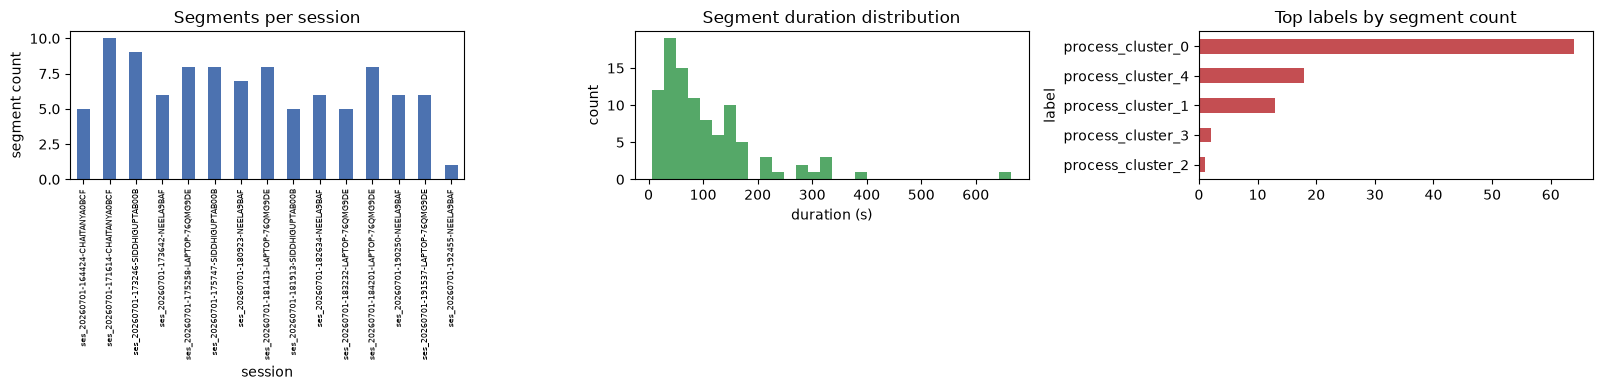

count     98.000000
mean     107.906439
std       98.658838
min        7.154000
25%       44.700000
50%       75.826000
75%      146.880000
max      664.046000
Name: pred_duration_s, dtype: float64


In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

segs_per_session.plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Segments per session")
axes[0].set_xlabel("session")
axes[0].set_ylabel("segment count")
axes[0].tick_params(axis="x", labelrotation=90, labelsize=6)

axes[1].hist(PREDICTED_SEGMENTS_B["pred_duration_s"], bins=30, color="#55A868")
axes[1].set_title("Segment duration distribution")
axes[1].set_xlabel("duration (s)")
axes[1].set_ylabel("count")

label_counts = PREDICTED_SEGMENTS_B["label"].value_counts().head(15)
label_counts.plot(kind="barh", ax=axes[2], color="#C44E52")
axes[2].invert_yaxis()
axes[2].set_title("Top labels by segment count")

plt.tight_layout()

summary_figure_path = OUTPUTS_DIR / "segmentation_summary_plots.png"
fig.savefig(summary_figure_path, dpi=150, bbox_inches="tight")
print("Saved:", summary_figure_path)

plt.show()

print(PREDICTED_SEGMENTS_B["pred_duration_s"].describe())

## Save `segments.jsonl`

Exactly the four required fields (`session_id`, `start`, `end`, `label`), ISO-8601 UTC with
a trailing `Z`, one JSON object per line -- matching the format in the README and
`DATA_SCHEMA.md` precisely.


In [17]:
segments_output_path = OUTPUTS_DIR / "segments.jsonl"

with open(segments_output_path, "w", encoding="utf-8") as f:
    for _, row in PREDICTED_SEGMENTS_B.sort_values(["session_id", "pred_start"]).iterrows():
        record = {
            "session_id": row["session_id"],
            "start": row["pred_start"].strftime("%Y-%m-%dT%H:%M:%SZ"),
            "end": row["pred_end"].strftime("%Y-%m-%dT%H:%M:%SZ"),
            "label": row["label"],
        }
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

print(f"Wrote {len(PREDICTED_SEGMENTS_B)} segments to {segments_output_path}")


Wrote 98 segments to c:\Users\Shambhavi Singh\OneDrive\Desktop\IBY_PROJECT\outputs\segments.jsonl


## Additional outputs ( process analysis / automation prioritization)




In [18]:
# --- segmentation_summary.csv ---
segmentation_summary = PREDICTED_SEGMENTS_B.merge(
    SEGMENT_FEATURES_B.drop(columns=["duration_s"]),
    on=["session_id", "pred_start", "pred_end"],
    how="left",
)
segmentation_summary_path = OUTPUTS_DIR / "segmentation_summary.csv"
segmentation_summary.to_csv(segmentation_summary_path, index=False)
print("Saved:", segmentation_summary_path, "-", segmentation_summary.shape)

# --- session_summary.csv ---
def parse_machine_id(session_id: str) -> str:
    # session_id format: ses_<date>-<time>-<machine>; machine id is everything after the
    # second '-'-delimited date/time token, which itself may contain hyphens.
    parts = session_id.split("-", 2)
    return parts[2] if len(parts) == 3 else "unknown"

session_summary_rows = []
for sid, g in PREDICTED_SEGMENTS_B.groupby("session_id"):
    session_events_count = (ALL_EVENTS_B["session_id"] == sid).sum()
    session_summary_rows.append({
        "session_id": sid,
        "machine_id_proxy_for_operator": parse_machine_id(sid),
        "n_events": int(session_events_count),
        "n_segments": int(len(g)),
        "session_start": session_bounds.loc[sid, "min"],
        "session_end": session_bounds.loc[sid, "max"],
        "session_duration_s": (session_bounds.loc[sid, "max"] - session_bounds.loc[sid, "min"]).total_seconds(),
        "n_unique_labels_in_session": int(g["label"].nunique()),
    })
session_summary = pd.DataFrame(session_summary_rows)
session_summary.attrs["caveat"] = (
    "machine_id_proxy_for_operator assumes one machine ~= one person; Dataset B carries no "
    "explicit operator identity field, so this is a weak proxy only -- do not treat it as a "
    "verified headcount."
)
session_summary_path = OUTPUTS_DIR / "session_summary.csv"
session_summary.to_csv(session_summary_path, index=False)
print("Saved:", session_summary_path, "-", session_summary.shape)
print("NOTE:", session_summary.attrs["caveat"])

# --- process_summary.csv ---
process_summary = PREDICTED_SEGMENTS_B.groupby("label").agg(
    n_occurrences=("label", "size"),
    n_sessions=("session_id", "nunique"),
    total_duration_s=("pred_duration_s", "sum"),
    mean_duration_s=("pred_duration_s", "mean"),
    median_duration_s=("pred_duration_s", "median"),
).reset_index()
process_summary["n_distinct_machines"] = process_summary["label"].map(
    lambda lbl: PREDICTED_SEGMENTS_B.loc[PREDICTED_SEGMENTS_B["label"] == lbl, "session_id"]
    .map(parse_machine_id).nunique()
)
process_summary = process_summary.sort_values("total_duration_s", ascending=False)
process_summary_path = OUTPUTS_DIR / "process_summary.csv"
process_summary.to_csv(process_summary_path, index=False)
print("Saved:", process_summary_path, "-", process_summary.shape)

# --- segmentation_quality_report.json ---
quality_report_path = OUTPUTS_DIR / "segmentation_quality_report.json"
with open(quality_report_path, "w", encoding="utf-8") as f:
    json.dump(quality_report, f, indent=2, default=str, ensure_ascii=False)
print("Saved:", quality_report_path)


Saved: c:\Users\Shambhavi Singh\OneDrive\Desktop\IBY_PROJECT\outputs\segmentation_summary.csv - (98, 26)
Saved: c:\Users\Shambhavi Singh\OneDrive\Desktop\IBY_PROJECT\outputs\session_summary.csv - (15, 8)
NOTE: machine_id_proxy_for_operator assumes one machine ~= one person; Dataset B carries no explicit operator identity field, so this is a weak proxy only -- do not treat it as a verified headcount.
Saved: c:\Users\Shambhavi Singh\OneDrive\Desktop\IBY_PROJECT\outputs\process_summary.csv - (5, 7)
Saved: c:\Users\Shambhavi Singh\OneDrive\Desktop\IBY_PROJECT\outputs\segmentation_quality_report.json


Final validation\n\nRe-load `segments.jsonl` from disk (not from the in-memory dataframe) and re-check the required-field contract and basic invariants, so the validation is against the actual artifact that will be submitted.

In [19]:
reloaded_segments = []
with open(segments_output_path, "r", encoding="utf-8") as f:
    for line_no, line in enumerate(f, start=1):
        try:
            record = json.loads(line)
        except json.JSONDecodeError as exc:
            raise AssertionError(f"segments.jsonl line {line_no} is not valid JSON: {exc}")
        missing = {"session_id", "start", "end", "label"} - set(record.keys())
        assert not missing, f"segments.jsonl line {line_no} missing required field(s): {missing}"
        reloaded_segments.append(record)

reloaded_df = pd.DataFrame(reloaded_segments)
reloaded_df["start"] = pd.to_datetime(reloaded_df["start"], utc=True)
reloaded_df["end"] = pd.to_datetime(reloaded_df["end"], utc=True)

assert (reloaded_df["start"] < reloaded_df["end"]).all(), "Found a reloaded segment with start >= end"
assert len(reloaded_df) == len(PREDICTED_SEGMENTS_B), "Reloaded segment count does not match in-memory count"

print(f"Final validation PASSED: {len(reloaded_df)} valid segment records in {segments_output_path.name}")
print("Required fields present on every line: session_id, start, end, label")
print("Distinct labels:", reloaded_df['label'].nunique())
print("Distinct sessions:", reloaded_df['session_id'].nunique())


Final validation PASSED: 98 valid segment records in segments.jsonl
Required fields present on every line: session_id, start, end, label
Distinct labels: 5
Distinct sessions: 15
